In [1]:
from gammaraytoys.detectors import ToyCodedMaskDetector3D
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.coordinates import Angle, SkyCoord, UnitSphericalRepresentation
from astropy.units import Quantity
from scipy.stats import poisson, norm, chi2
from histpy import Histogram, Axis

from gammaraytoys import poisson_binned_log_likelihood, unbinned_log_likelihood, richardson_lucy
from gammaraytoys.analysis import FastNormFit

from scipy.stats import norm, chi2

import cProfile

%load_ext line_profiler

In [2]:
det = ToyCodedMaskDetector3D.create_random_mask(mask_size = 40 * u.cm, 
                                                mask_npix = 130, 
                                                mask_separation = 100 * u.cm, 
                                                open_fraction = .5, 
                                                detector_size = 22 * u.cm, 
                                                detector_npix = 440, 
                                                detector_efficiency = 0.65)

In [3]:
coord = SkyCoord(l = -10*u.deg, b = -10*u.deg, frame = 'galactic')

flux = 1/u.cm/u.cm/u.s
duration = 1*u.s

54.4549437563938


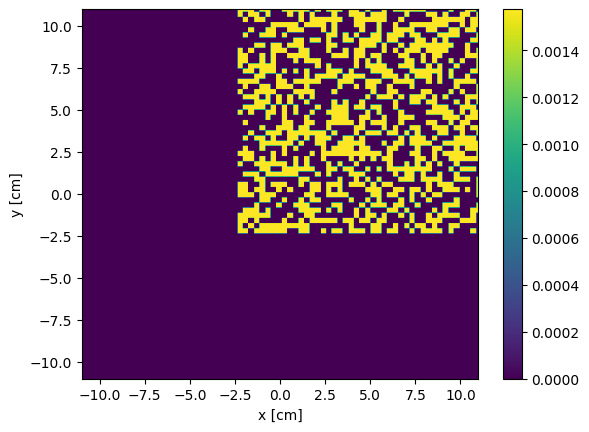

In [4]:
shadowgram = det.point_source_response(flux, duration, coord)
print(np.sum(shadowgram))
shadowgram.plot();

55.82821648701357


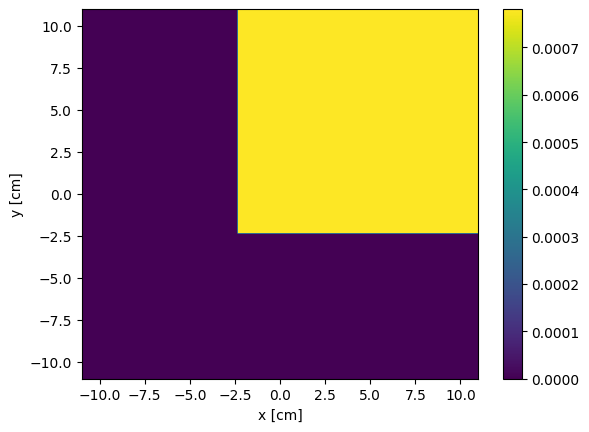

In [6]:
shadowgram_nonimg = det.point_source_response(flux, duration, coord, imaging = False)
ax,_= shadowgram_nonimg.plot()
print(np.sum(shadowgram_nonimg))

In [15]:
np.sum(shadowgram)

np.float64(92.77183254576899)

np.float64(1061.3206057749246)

In [105]:
5.88e-2*(.5/1)**-1.75 * (1/u.cm/u.cm/u.s/u.sr/u.MeV) * (.511 *u.MeV * .02)

<Quantity 0.0020213 1 / (s sr cm2)>

In [106]:
0.02 * (1/511) * (1/u.cm/u.cm/u.s/u.sr/u.keV) * (511 *u.keV * .02)

<Quantity 0.0004 1 / (s sr cm2)>

(<Axes: xlabel='lon [deg]', ylabel='lat [deg]'>,
 <matplotlib.collections.QuadMesh at 0x1308ef5d0>)

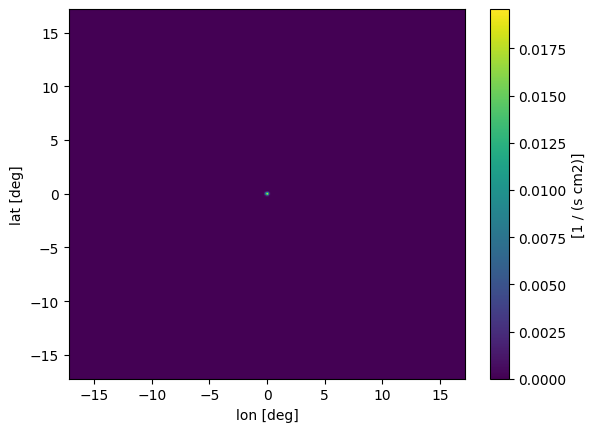

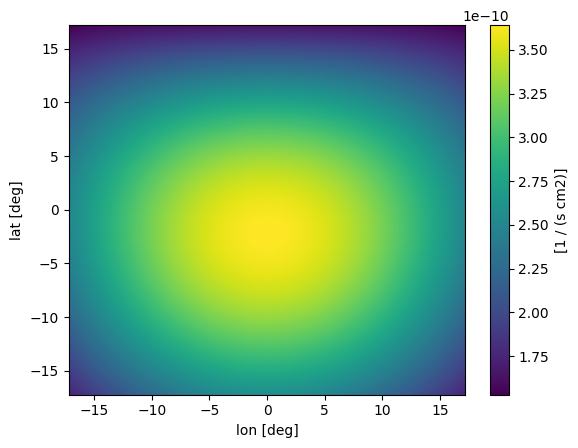

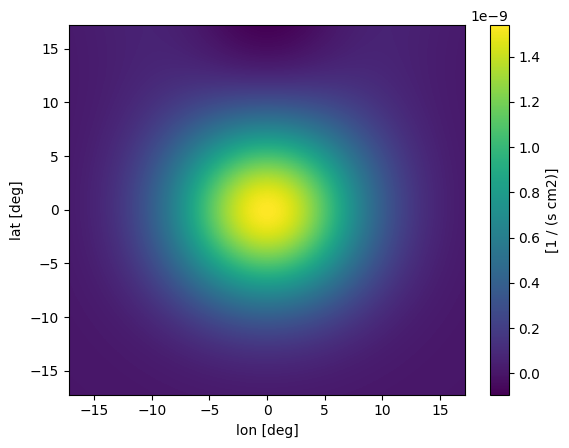

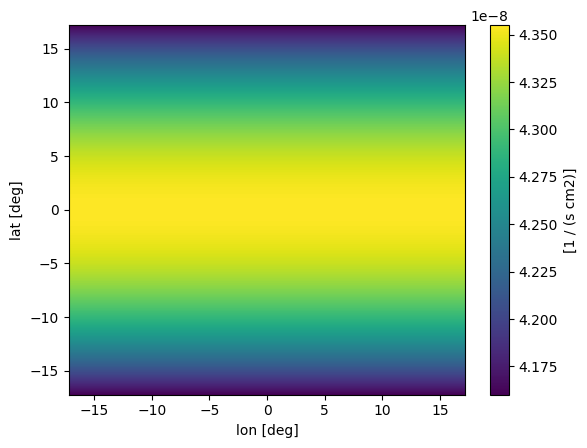

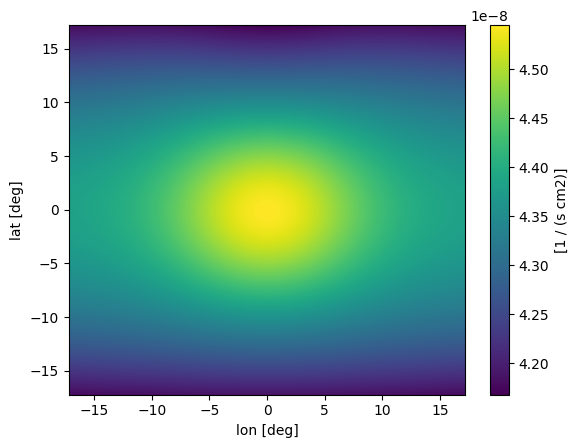

In [6]:
flux = 1/u.cm/u.cm/u.s
coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 0*u.deg)

width_lon = .1*u.deg
width_lat = .1*u.deg

model = det.gaussian_model(flux, coord, width_lon, width_lat, max_sigma = 3)
model.plot()

wider_bulge_model = det.gaussian_model(7.3e-4/u.cm/u.cm/u.s, coord, 20*u.deg, 20*u.deg, max_sigma = 3)
wider_bulge_model.plot()

narrow_bulge_model = det.gaussian_model(2.8e-4/u.cm/u.cm/u.s, coord, 6*u.deg, 6*u.deg, max_sigma = 3)
narrow_bulge_model.plot()

bkg_model = det.isotropic_diffuse_model((0.02 + 0.095)/u.cm/u.cm/u.s/u.sr)
bkg_model.plot()

bkg_all_model = narrow_bulge_model+wider_bulge_model+bkg_model

bkg_all_model.plot()

In [7]:
duration = 2*u.year
signal = det.convolve_model(model, duration)
bkg = det.convolve_model(bkg_all_model.rebin(20,20), duration, imaging = False)

100%|██████████| 2304/2304 [00:08<00:00, 277.98it/s]


(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x1304ff190>)

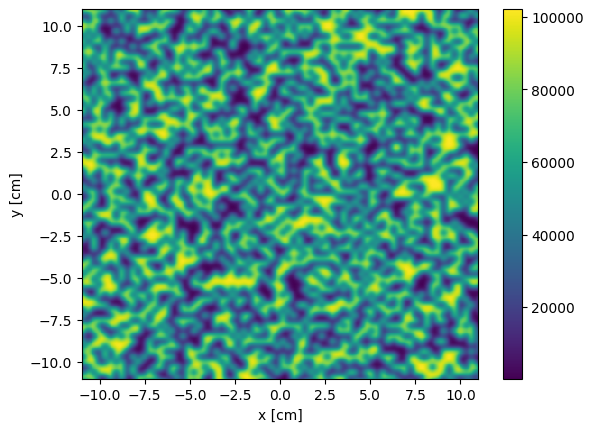

In [8]:
signal.plot()

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x12ffb0b50>)

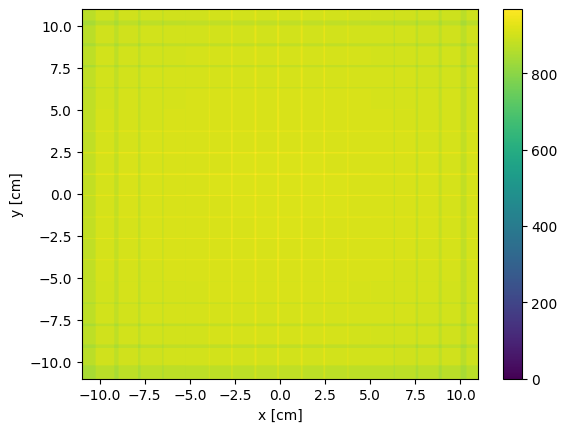

In [9]:
bkg.plot(vmin = 0)

In [10]:
signal_factor = .5e-4
tot_signal = np.sum(signal_factor*signal)
tot_bkg = np.sum(bkg)
tot_signal/np.sqrt(tot_bkg)

np.float64(37.2621604168109)

In [11]:
(tot_bkg/duration).to(u.Hz)

<Quantity 2.76742952 Hz>

In [97]:
fnf = FastNormFit()

data = bkg + signal_factor*signal

_,null_excess_norm,_,_ = fnf.solve(data, bkg, bkg)

null_excess_norm

np.float64(0.002833930151796137)

In [101]:
log_like = poisson_binned_log_likelihood(data.contents, data.contents)
log_like_null = poisson_binned_log_likelihood(data.contents, (1+null_excess_norm) * bkg.contents)
ts = 2*(log_like - log_like_null)

norm.isf(chi2.sf(ts, df = 2)) # df: source norm, bkg norm

np.float64(16.115084910412484)

In [23]:
bkg_uniform = det.uniform_bkg(np.sum(bkg)/duration, duration)

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x129d06b10>)

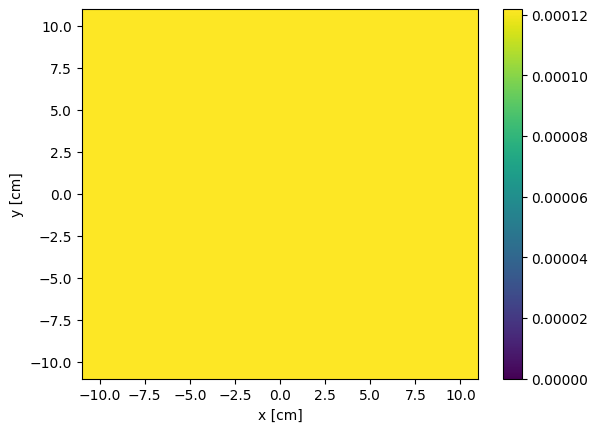

In [24]:
bkg_uniform.plot(vmin = 0)

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x128c50890>)

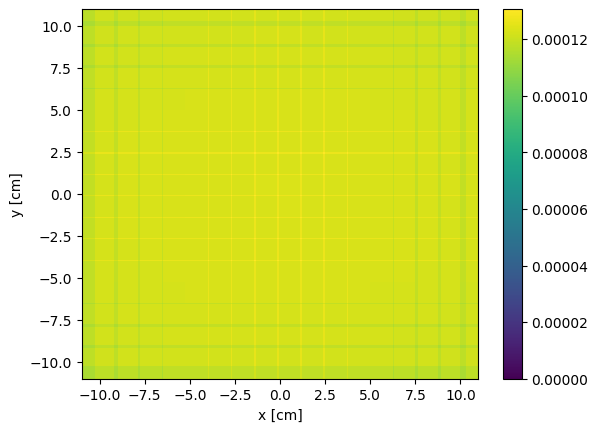

In [19]:
bkg.plot(vmin = 0)

In [17]:
expectation.contents.flatten()

array([0.00015884, 0.00162476, 0.00162476, ..., 0.00028382, 0.00162476,
       0.00162476])

In [13]:
poisson_binned_log_likelihood(expectation.contents.flatten(), )

Signature: poisson_binned_log_likelihood(data, expectation)
Docstring: <no docstring>
File:      ~/software/gammaraytoys/gammaraytoys/analysis/likelihoods.py
Type:      function

In [ ]:
expectation

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x132ccc6d0>)

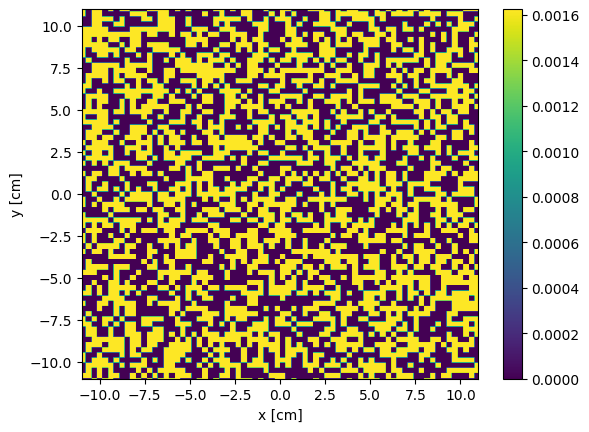

In [12]:
expectation.plot()

(<Axes: xlabel='lon [deg]', ylabel='lat [deg]'>,
 <matplotlib.collections.QuadMesh at 0x1315a7990>)

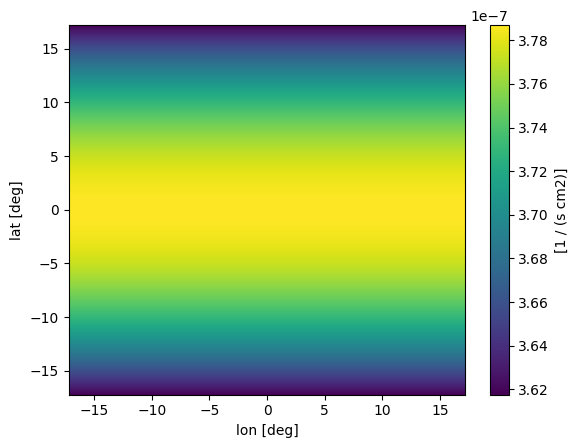

In [6]:
det.isotropic_diffuse_model(1/u.cm/u.cm/u.s/u.sr).plot()

In [12]:
(2*u.deg * np.sin(59*u.deg) * u.rad / u.sr).to('')

<Quantity 0.02992078>

In [5]:
det.uniform_bkg(1/u.s, 1*u.s)

np.float64(1.0000000000000002)

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x133fe16d0>)

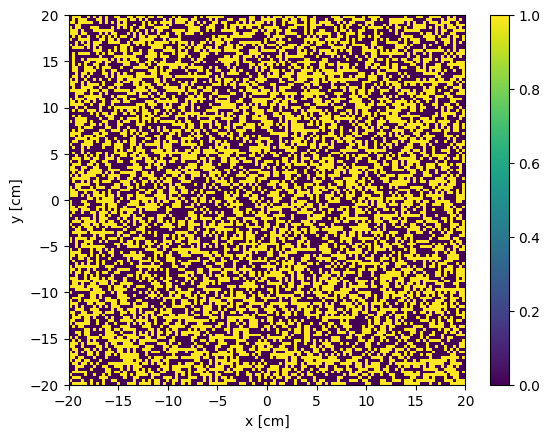

In [3]:
det.mask.plot()

In [3]:
coord = SkyCoord(l = 0.1*u.deg, b = 1*u.deg, frame = 'galactic')

flux = 1/u.cm/u.cm/u.s
duration = 1*u.s

shadowgram = det.point_source_response(flux, duration, coord)

shadowgram_nonimg = det.point_source_nonimg_response(flux, duration, coord)

shadowgram.plot()
shadowgram_nonimg.plot()

TypeError: only dimensionless scalar quantities can be converted to Python scalars

In [5]:
det.sky_axes.nbins

array([976, 976])

In [3]:
flux = 1/u.cm/u.cm/u.s
coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 0*u.deg)
width_lon = 10*det.angular_resolution
width_lat = 10*det.angular_resolution

model = det.gaussian_model(flux, coord, width_lon, width_lat)

flux = 1e-2/u.cm/u.cm/u.s
coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 0*u.deg)
width_lon = 1*det.angular_resolution
width_lat = 1*det.angular_resolution

model += det.gaussian_model(flux, coord, width_lon, width_lat)

flux = 1e-2/u.cm/u.cm/u.s
coord = UnitSphericalRepresentation(lon = 0*u.deg, lat = 4*u.deg)
width_lon = 1*det.angular_resolution
width_lat = 1*det.angular_resolution

model += det.gaussian_model(flux, coord, width_lon, width_lat)

UnitConversionError: Specify units

In [38]:
np.sum(model)

<Quantity 1.0047432 1 / (s cm2)>

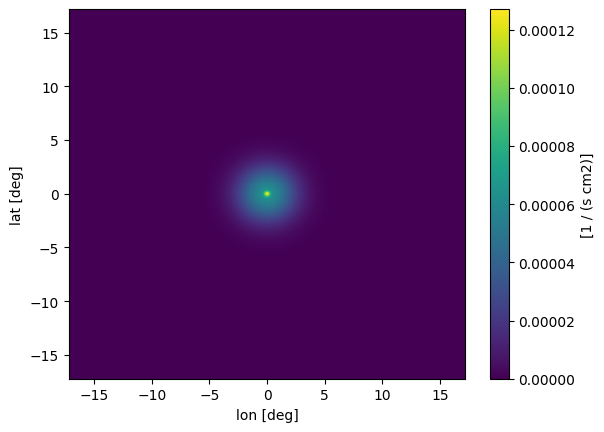

In [39]:
ax, _  = model.plot()

# ax.set_xlim(-1,1)
# ax.set_ylim(-1,1)

In [ ]:
model.plot()

In [ ]:
lon_unit,lat_unit

In [ ]:
det.response.contents.value.size*8*1e4/1e9

In [ ]:
import sys

sys.getsizeof(det.response.contents.value)

In [ ]:
50*1e4/3600

In [ ]:
det.response.project(0,1).plot()

In [ ]:
det.response.slice[0,1].project(2,3).plot()

In [ ]:
(np.prod(det.sky_axes.nbins) * np.prod(det.detector_axes.nbins)) * 8 / 1e9

In [ ]:
np.sum(shadowgram)

In [ ]:
cProfile.run('det.point_source_response(1/u.cm/u.cm/u.s, 1*u.s, coord)', filename = "psr.prof")

In [ ]:
%lprun -f det.point_source_response.__wrapped__ det.point_source_response(1/u.cm/u.cm/u.s, 1*u.s, coord)

In [ ]:
fig,ax = plt.subplots(subplot_kw={'projection':'3d'})

ax.plot_surface

In [ ]:
[[]]*10

In [ ]:
a = np.full(10, tuple([]), dtype = object)

In [ ]:
for mask_i, geom_weight in [[1, .5]]:
    print(mask_i, geom_weight)

In [ ]:
a[0] = tuple([[1, .5]])

In [ ]:
a

In [ ]:
x = [3,4,5]
x += [5,6]

In [ ]:
x